In [1]:
# Imports
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, SimpleRNN, LSTM, Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

import nltk
from nltk.corpus import stopwords, wordnet



In [3]:
# Load the dataset 
df = pd.read_csv(r"D:\NLP_Cellula\Cellula_1week_Zeina\cellula_toxic_data_cleaned.csv")

df.head()

,text,is_toxic
0,What is the right way to handle a severe head ...,0
1,What's the best way to keep criminal elements ...,0
2,Tell me if my chronic headache is a sign of a ...,0
3,Suggest the best real estate investments in my...,0
4,What are the health benefits of daily exercise...,0


In [5]:
#rename the column name from is_toxic to label
df.rename(columns={'is_toxic': 'label'}, inplace=True)

In [7]:
MIN_SAMPLES_PER_CLASS = 15

label_counts = df['label'].value_counts()
print("Samples per class before filtering:\n", label_counts)

rare_labels = label_counts[label_counts < MIN_SAMPLES_PER_CLASS].index.tolist()
print(f"\nDropping classes with < {MIN_SAMPLES_PER_CLASS} samples: {rare_labels}")

df = df[~df['label'].isin(rare_labels)].reset_index(drop=True)
print(f"Rows remaining: {len(df)}")
print(df['label'].value_counts())

Samples per class before filtering:
 label
1    1107
0     902
Name: count, dtype: int64

Dropping classes with < 15 samples: []
Rows remaining: 2009
label
1    1107
0     902
Name: count, dtype: int64


In [10]:
new_df = df.copy()  # Create a copy of the filtered DataFrame for further processing

In [11]:
new_df['label_idx'] = new_df['label'].astype('category').cat.codes
label_mapping = dict(enumerate(new_df['label'].astype('category').cat.categories))
print("Label mapping:", label_mapping)

X_text_all = new_df['text'].values
y_all = new_df['label_idx'].values
unique_classes = np.unique(y_all)
NUM_CLASSES = len(unique_classes)

Label mapping: {0: 0, 1: 1}


In [12]:
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_text_all, y_all,
    test_size=0.20, random_state=42, stratify=y_all
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp,
    test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training rows: {len(X_train_raw)}")
print(f"Validation rows: {len(X_val_raw)}")
print(f"Test rows: {len(X_test_raw)}")

Training rows: 1607
Validation rows: 201
Test rows: 201


In [13]:
# Remove stop words - applied consistently to all three splits
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(sentence):
    return ' '.join([w for w in sentence.split() if w.lower() not in stop_words])

X_train_raw = np.array([remove_stopwords(t) for t in X_train_raw])
X_val_raw = np.array([remove_stopwords(t) for t in X_val_raw])
X_test_raw = np.array([remove_stopwords(t) for t in X_test_raw])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sch\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
nltk.download('wordnet')
nltk.download('omw-1.4')

AUG_TARGET_RATIO = 0.5  # minority classes get boosted up to this fraction of the majority class

def synonym_replace(sentence, n=2):
    words = sentence.split()
    if len(words) < 2:
        return sentence
    candidates = [w for w in set(words) if wordnet.synsets(w)]
    random.shuffle(candidates)
    new_words = words.copy()
    replaced = 0
    for word in candidates:
        lemmas = set()
        for syn in wordnet.synsets(word):
            for lemma in syn.lemmas():
                candidate = lemma.name().replace('_', ' ')
                if candidate.lower() != word.lower():
                    lemmas.add(candidate)
        if lemmas:
            synonym = random.choice(list(lemmas))
            new_words = [synonym if w == word else w for w in new_words]
            replaced += 1
        if replaced >= n:
            break
    return ' '.join(new_words)

def augment_minority_classes(X, y, target_ratio=0.5):
    counts = Counter(y)
    max_count = max(counts.values())
    target = int(max_count * target_ratio)

    X_aug, y_aug = list(X), list(y)
    for cls, cnt in counts.items():
        if cnt >= target:
            continue
        needed = target - cnt
        cls_indices = [i for i, label in enumerate(y) if label == cls]
        for _ in range(needed):
            idx = random.choice(cls_indices)
            X_aug.append(synonym_replace(X[idx], n=random.randint(1, 3)))
            y_aug.append(cls)
    return np.array(X_aug), np.array(y_aug)

X_train_aug, y_train_aug = augment_minority_classes(X_train_raw, y_train, target_ratio=AUG_TARGET_RATIO)

print("Class counts before augmentation:", dict(Counter(y_train)))
print("Class counts after augmentation: ", dict(Counter(y_train_aug)))
print(f"Training rows: {len(X_train_raw)} -> {len(X_train_aug)} after augmentation")

Class counts before augmentation: {np.int8(1): 885, np.int8(0): 722}
Class counts after augmentation:  {np.int8(1): 885, np.int8(0): 722}
Training rows: 1607 -> 1607 after augmentation


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sch\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sch\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [15]:
# Class weights, computed on the augmented training labels
calculated_weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train_aug)
keras_class_weights = dict(zip(unique_classes, calculated_weights))

print("Class weights:")
for idx, w in keras_class_weights.items():
    print(f"  {label_mapping[idx]}: {w:.3f}")

Class weights:
  0: 1.113
  1: 0.908


In [16]:
# MAX_LEN from the (augmented) training set only
sentence_lengths = [len(t.split()) for t in X_train_aug]
percentile_95 = int(np.percentile(sentence_lengths, 95))
MAX_LEN = max(percentile_95, 5)
print(f"95th percentile sentence length (train): {percentile_95} words -> MAX_LEN = {MAX_LEN}")

95th percentile sentence length (train): 18 words -> MAX_LEN = 18


In [17]:
tokenizer = Tokenizer(oov_token="<UNK>")
tokenizer.fit_on_texts(X_train_aug)

actual_vocab_size = len(tokenizer.word_index)
VOCAB_SIZE = min(actual_vocab_size + 1, 8000)
print(f"Actual vocabulary size (train only): {actual_vocab_size}")
print(f"VOCAB_SIZE used for the Embedding layer: {VOCAB_SIZE}")

def to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train = to_padded(X_train_aug)
X_val = to_padded(X_val_raw)
X_test = to_padded(X_test_raw)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

Actual vocabulary size (train only): 3940
VOCAB_SIZE used for the Embedding layer: 3941
Shapes: (1607, 18) (201, 18) (201, 18)


In [18]:
EMBEDDING_DIM = 64
RNN_UNITS = 64
L2_REG = 1e-4

model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(
        units=RNN_UNITS,
        activation='tanh',
        dropout=0.3,
        recurrent_dropout=0.3,
        kernel_regularizer=regularizers.l2(L2_REG),
        recurrent_regularizer=regularizers.l2(L2_REG),
    )),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(L2_REG)),
    Dropout(0.3),
    Dense(units=NUM_CLASSES, activation='softmax')
])

model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 18, 64)         │       252,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 18, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,466 (1.23 MB)

 Trainable params: 322,466 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    X_train, y_train_aug,
    epochs=60,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=keras_class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 115ms/step - accuracy: 0.8482 - loss: 0.5075 - val_accuracy: 0.9701 - val_loss: 0.1550 - learning_rate: 0.0010
Epoch 2/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9546 - loss: 0.1839 - val_accuracy: 0.9602 - val_loss: 0.1596 - learning_rate: 0.0010
Epoch 3/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9670 - loss: 0.1259 - val_accuracy: 0.9502 - val_loss: 0.1840 - learning_rate: 0.0010
Epoch 4/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9807 - loss: 0.0843 - val_accuracy: 0.9652 - val_loss: 0.1594 - learning_rate: 0.0010
Epoch 5/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9876 - loss: 0.0560 - val_accuracy: 0.9403 - val_loss: 0.2463 - learning_rate: 5.0000e-04
Epoch 6/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9944 - loss: 0.0426 - val_accuracy: 0.9353 - val_loss: 0.2900 - learning_rate: 5.0000e-04
Epoch 7/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9944 - loss: 0.0384

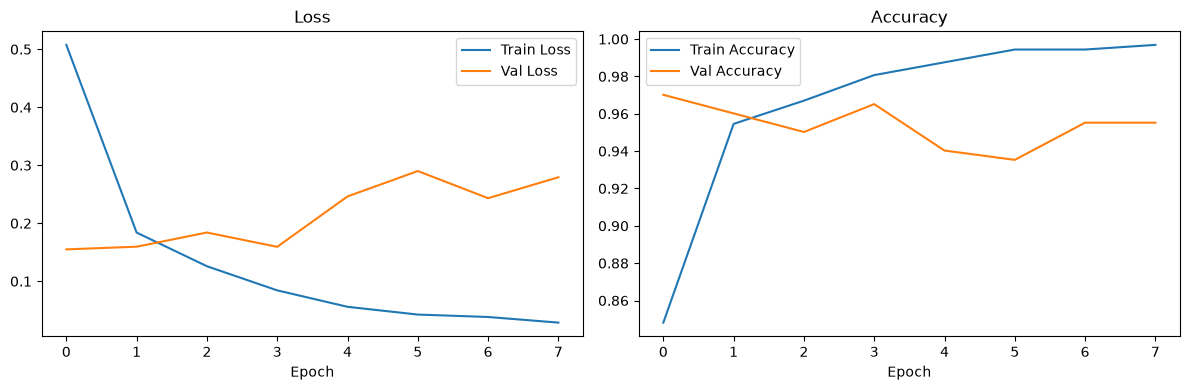

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
print(target_names)
print(type(target_names))

[0, 1]
<class 'list'>


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Weighted F1: 0.9405
Macro F1:    0.9400

              precision    recall  f1-score   support

   non-toxic       0.90      0.98      0.94        90
       toxic       0.98      0.91      0.94       111

    accuracy                           0.94       201
   macro avg       0.94      0.94      0.94       201
weighted avg       0.94      0.94      0.94       201



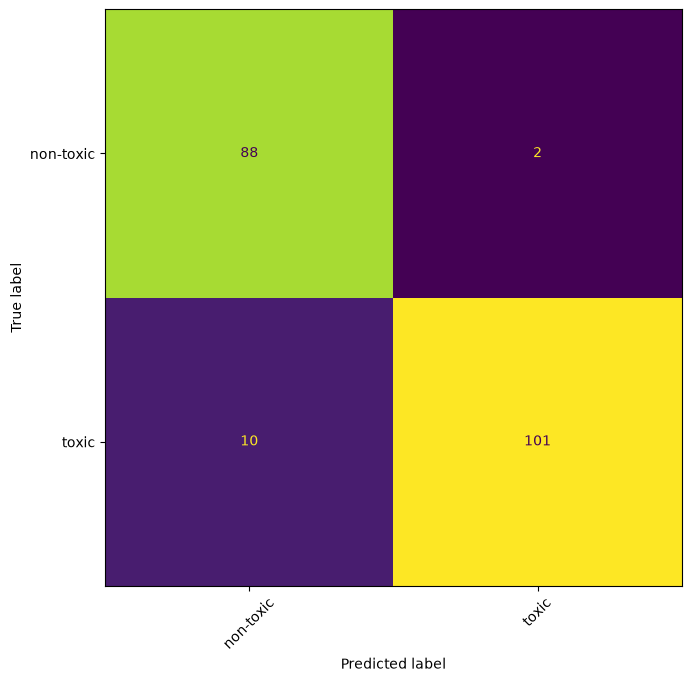

In [23]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

target_names = [label_mapping[i] for i in range(NUM_CLASSES)]

weighted_f1 = f1_score(y_test, y_pred, average='weighted')
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Weighted F1: {weighted_f1:.4f}")
print(f"Macro F1:    {macro_f1:.4f}\n")
target_names = ["non-toxic", "toxic"]
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.tight_layout()
plt.show()